Files already downloaded and verified
Files already downloaded and verified


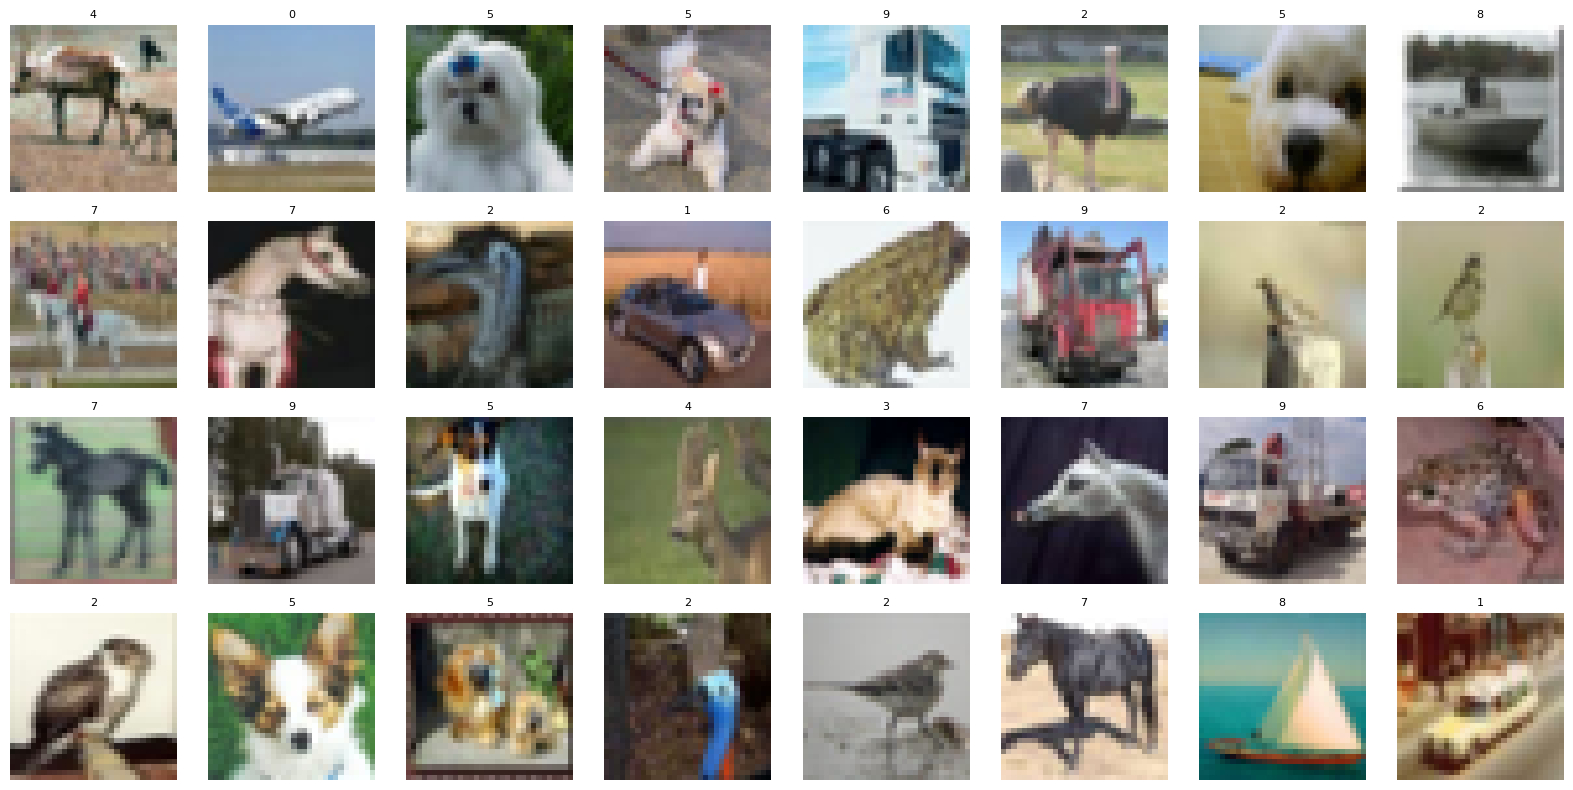

In [6]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Define transformation: convert to tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize RGB channels
])

# Download and load CIFAR-10 dataset
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Create DataLoader objects
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Show a batch of training images and their labels
examples = next(iter(train_loader))
images, labels = examples

# Unnormalize for visualization
def unnormalize(img):
    img = img * 0.5 + 0.5  # reverse normalization
    return img

# CIFAR-10 class labels
classes = train_dataset.classes

# Plot batch

plt.figure(figsize=(16, 8))
for i in range(32):
    plt.subplot(4, 8, i + 1)
    img = images[i] * 0.5 + 0.5  # unnormalize
    plt.imshow(img.permute(1, 2, 0))
    plt.title(f'{labels[i].item()}', fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()


Files already downloaded and verified
Files already downloaded and verified
Training with SGD + Momentum
Epoch 1: Train Loss=1.8055, Train Acc=0.3352, Val Loss=1.5478, Val Acc=0.4472
Epoch 2: Train Loss=1.4187, Train Acc=0.4879, Val Loss=1.3580, Val Acc=0.5093
Epoch 3: Train Loss=1.2758, Train Acc=0.5496, Val Loss=1.2729, Val Acc=0.5549
Epoch 4: Train Loss=1.1788, Train Acc=0.5829, Val Loss=1.2385, Val Acc=0.5589
Epoch 5: Train Loss=1.1015, Train Acc=0.6113, Val Loss=1.2465, Val Acc=0.5698
Epoch 6: Train Loss=1.0391, Train Acc=0.6374, Val Loss=1.1903, Val Acc=0.5850
Epoch 7: Train Loss=0.9870, Train Acc=0.6527, Val Loss=1.1790, Val Acc=0.5939
Epoch 8: Train Loss=0.9466, Train Acc=0.6665, Val Loss=1.1708, Val Acc=0.6022
Epoch 9: Train Loss=0.9084, Train Acc=0.6815, Val Loss=1.2110, Val Acc=0.5902
Epoch 10: Train Loss=0.8846, Train Acc=0.6885, Val Loss=1.2443, Val Acc=0.5834
Epoch 11: Train Loss=0.8499, Train Acc=0.7000, Val Loss=1.2819, Val Acc=0.5948
Epoch 12: Train Loss=0.8197, Train 

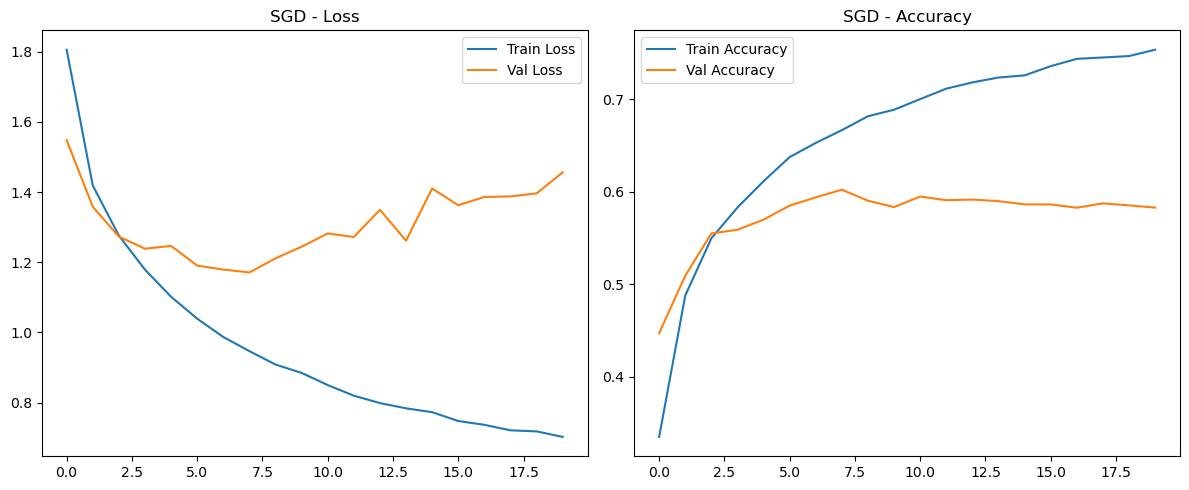

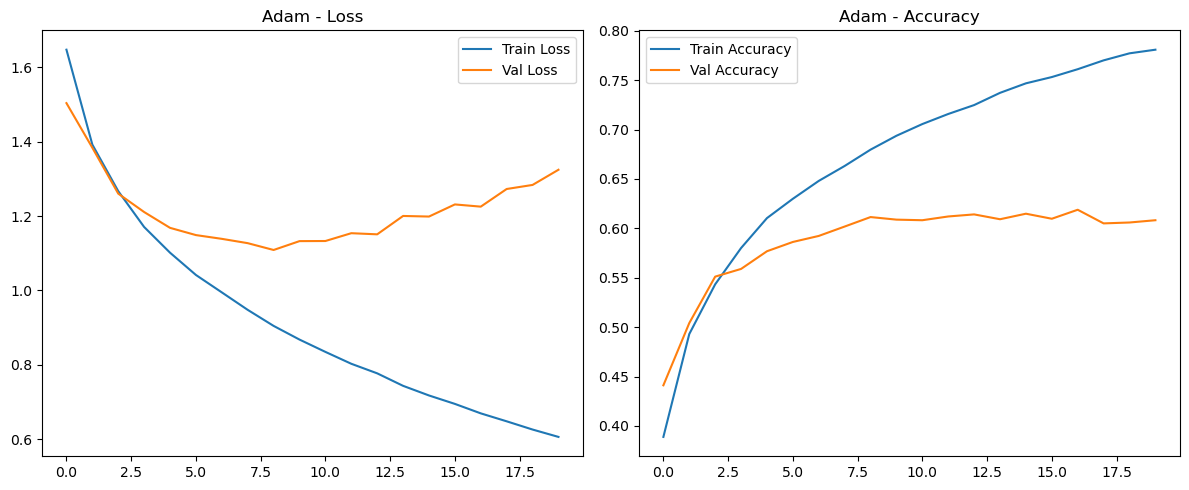


Evaluating SGD Model
Accuracy: 0.5834
Precision: 0.5847
Recall: 0.5834
F1 Score: 0.5833
Confusion Matrix:
 [[615  37  69  48  28  19   8  23 100  53]
 [ 41 744  13  18   7  13  11   8  47  98]
 [ 69  10 502 100  80  69  64  60  28  18]
 [ 22  19 102 354  69 228  93  62  20  31]
 [ 24  12  97 125 460  62  68 127  15  10]
 [ 15   5 104 162  37 490  39 111  15  22]
 [ 15  10  73 101  70  52 636  17  12  14]
 [ 21   8  54  55  57  73  23 659   8  42]
 [123  48  22  19   7  22   6  10 710  33]
 [ 48 123  10  34  14  29   9  30  39 664]]

Evaluating Adam Model
Accuracy: 0.6105
Precision: 0.6145
Recall: 0.6105
F1 Score: 0.6104
Confusion Matrix:
 [[676  37  58  23  36  15  23  11  78  43]
 [ 35 751  17  13   8  11  18   4  38 105]
 [ 87   7 481  79  99  81 104  34  18  10]
 [ 27   9  83 447  65 183 117  32  18  19]
 [ 26   5  91  80 541  52 116  76   8   5]
 [ 17   9  76 217  60 494  55  54   8  10]
 [  5   6  48  67  40  30 788   6   6   4]
 [ 14   5  56  69  99  97  20 608   4  28]
 [121  6

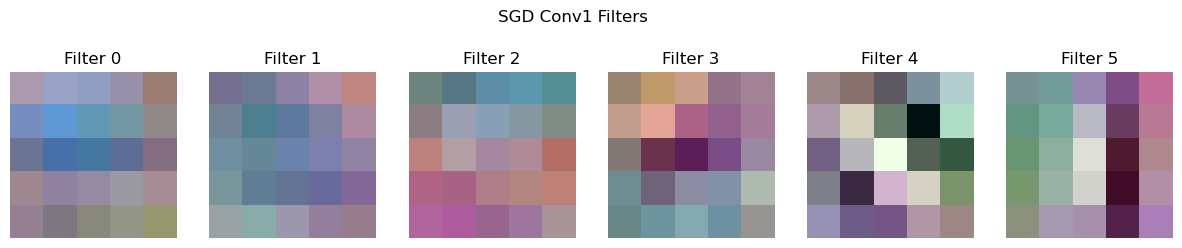

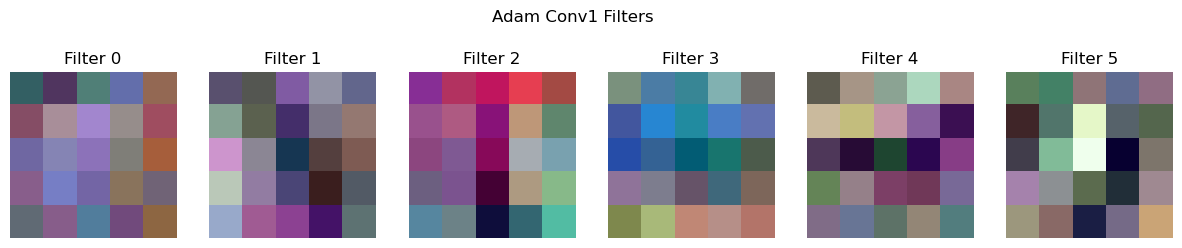

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# -----------------------------
# 1. Data Preparation
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Split train into train/validation
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_data, val_data = torch.utils.data.random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# -----------------------------
# 2. Define CNN Model
# -----------------------------
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# -----------------------------
# 3. Training Function
# -----------------------------
def train_model(model, optimizer, criterion, train_loader, val_loader, epochs=20):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    best_acc = 0.0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct, total = 0, 0

        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_losses.append(running_loss / len(train_loader))
        train_accuracies.append(correct / total)

        # Validation
        model.eval()
        val_loss = 0
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_losses.append(val_loss / len(val_loader))
        val_acc = correct / total
        val_accuracies.append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            best_model_state = model.state_dict()

        print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Train Acc={train_accuracies[-1]:.4f}, Val Loss={val_losses[-1]:.4f}, Val Acc={val_acc:.4f}")

    return train_losses, val_losses, train_accuracies, val_accuracies, best_model_state

# -----------------------------
# 4. Plot Metrics
# -----------------------------
def plot_metrics(train_losses, val_losses, train_accs, val_accs, title):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Val Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

# -----------------------------
# 5. Evaluation Function
# -----------------------------
def evaluate_model(model, model_state, test_loader):
    model.load_state_dict(model_state)
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            y_true.extend(labels.tolist())
            y_pred.extend(predicted.tolist())

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    cm = confusion_matrix(y_true, y_pred)

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:\n", cm)

# -----------------------------
# 6. Visualize Filters
# -----------------------------
def visualize_weights(model_state, title):
    model = CNN()
    model.load_state_dict(model_state)
    weights = model.conv1.weight.data.clone()
    weights = (weights - weights.min()) / (weights.max() - weights.min())  # Normalize for display

    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    for i in range(6):
        axes[i].imshow(weights[i].permute(1, 2, 0))
        axes[i].axis('off')
        axes[i].set_title(f'Filter {i}')
    plt.suptitle(title)
    plt.show()

# -----------------------------
# 7. Run Training for SGD and Adam
# -----------------------------
model_sgd = CNN()
model_adam = CNN()
criterion = nn.CrossEntropyLoss()
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.001)

print("Training with SGD + Momentum")
sgd_results = train_model(model_sgd, optimizer_sgd, criterion, train_loader, val_loader)
print("\nTraining with Adam")
adam_results = train_model(model_adam, optimizer_adam, criterion, train_loader, val_loader)

# -----------------------------
# 8. Plot Metrics
# -----------------------------
plot_metrics(*sgd_results[:4], title="SGD")
plot_metrics(*adam_results[:4], title="Adam")

# -----------------------------
# 9. Save Best Models
# -----------------------------
torch.save(sgd_results[4], "best_cnn_sgd.pth")
torch.save(adam_results[4], "best_cnn_adam.pth")

# -----------------------------
# 10. Evaluate on Test Set
# -----------------------------
print("\nEvaluating SGD Model")
evaluate_model(model_sgd, sgd_results[4], test_loader)
print("\nEvaluating Adam Model")
evaluate_model(model_adam, adam_results[4], test_loader)

# -----------------------------
# 11. Visualize Filters
# -----------------------------
visualize_weights(sgd_results[4], "SGD Conv1 Filters")
visualize_weights(adam_results[4], "Adam Conv1 Filters")